# 00 · The whole story in one notebook

**Build Your First AI Agent: From Machine Learning & LLMs to Real-World Workflows**

This notebook runs the complete flow, start to finish, in about 10 minutes of reading.
The other notebooks (01-05) go deeper into each step.

| Chapter | What happens | Helper it creates |
|---|---|---|
| 1. Give an LLM hands | An LLM gets tools, so it can look things up and act | 🔵 Senior expert |
| 2. The LLM teaches ML | The LLM labels messages; a small ML model learns from them | 🟢 Receptionist |
| 3. The whole support office | Each message goes to the cheapest helper that can answer it | + 🟡 Junior, 🔴 Manager |

> **This notebook costs $0 to run.** Every LLM answer in it was saved the first time
> (`data/saved_llm_answers.jsonl`), so it is replayed instead of paid for again.

In [1]:
import sys
sys.path.append("..")   # so Python can find the budget_agent folder

import pandas as pd
pd.set_option("display.max_colwidth", 80)
from dotenv import load_dotenv
load_dotenv("../.env")

from IPython.display import Image
from budget_agent import config, data
from budget_agent.llm import make_llm

saved_before = len(config.REPLAY_LOG.read_text().splitlines())   # to prove we spend nothing
llm = make_llm()
print("Cloud LLM:", llm.provider, llm.model)

Cloud LLM: openai gpt-5.4-mini


## Setup: the shop

**NovaMart** is a pretend online shop. We have customer messages (each with the *intent*: what the customer wants)
and a table of orders the agent can look up.

In [2]:
messages = data.load_messages()
print(len(messages), "customer messages,", messages.true_intent.nunique(), "intents")
messages.sample(3, random_state=4)[["text", "true_intent"]]

1620 customer messages, 27 intents


,text,true_intent
315,can you help me changing to the standard account?,switch_account
1481,wanna see what delivery options are there i need help,delivery_options
1616,I do not know what to do to report errors with registrations,registration_problems


In [3]:
orders = data.load_orders()
orders[orders.order_id.isin(["NM10009", "NM10002", "NM10018"])]

,order_id,customer_name,city,product,quantity,amount_inr,order_date,status,delivery_date
2,NM10002,Aarav Rao,Pune,Smart Watch,1,5999,2026-09-20,Delivered,2026-09-26
9,NM10009,Rohan Das,Bengaluru,Running Shoes,1,3299,2026-09-12,Shipped,2026-10-08
18,NM10018,Sneha Mehta,Mumbai,Office Chair,1,12999,2026-09-27,Delivered,2026-10-02


These three orders are our examples all the way through:
NM10009 (shipped shoes), NM10002 (a ₹5,999 watch that arrived broken), NM10018 (a ₹12,999 chair).

---
## Chapter 1: Build your first AI agent

### First, the LLM alone. Can it help?

In [4]:
from budget_agent.agent import SupportAgent

alone = SupportAgent(use_tools=False, llm=llm)
r = alone.run("where is my order NM10009?")
print(r.reply)

Sorry, I can’t access order tracking or customer accounts from here. Please check the tracking link in your order confirmation email, or contact NovaMart support with order ID **NM10009** and your registered phone/email. If you want, I can help you draft a message to support.


It's polite, but it **can't see the order**. An LLM only knows text; it has no access to our systems.

### Now give it tools

A *tool* is a normal Python function (`lookup_order`, `start_refund`, `cancel_order`, `escalate_to_human`...).
The LLM can only **ask** for a tool. Our code runs it and sends back the result. That's the **agent loop**:

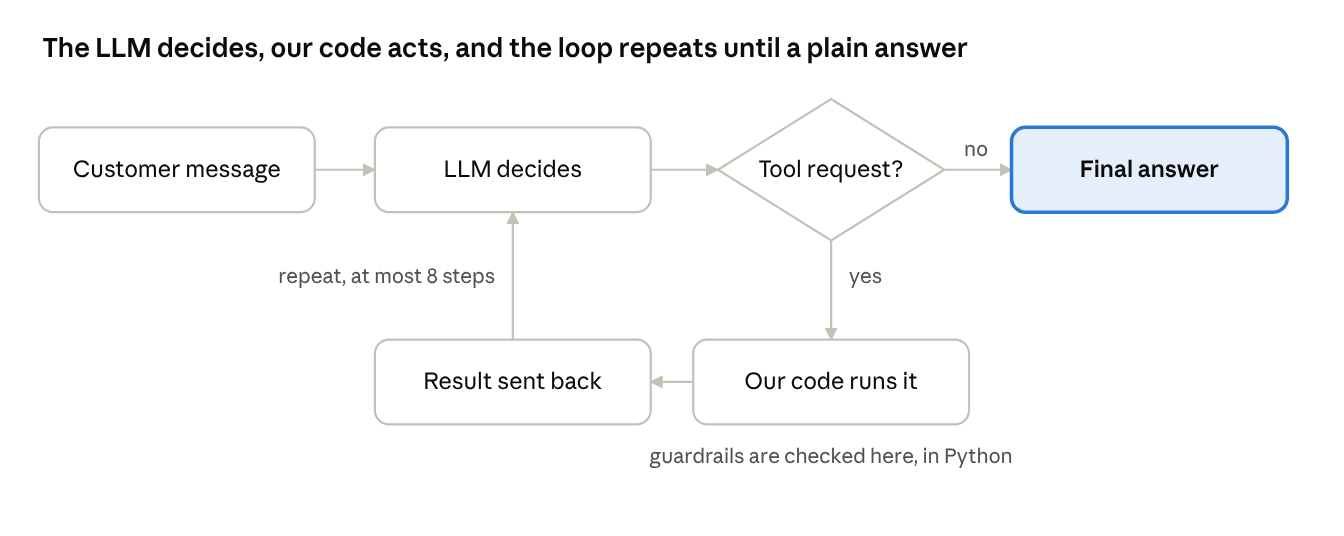

In [5]:
Image("../docs/images/agent-loop.png", width=700)

In [6]:
def show(result):
    for name, tool_input, output in result.tool_calls:
        print(f"🔧 {name}({tool_input})")
    print(f"💬 {result.reply}")
    print(f"   {len(result.calls)} LLM calls · ${result.cost_usd:.4f} (when first made)")

expert = SupportAgent(use_tools=True, llm=llm)
show(expert.run("where is my order NM10009?"))

🔧 lookup_order({'order_id': 'NM10009'})
💬 Your order NM10009 is shipped and expected to be delivered on 08 Oct 2026. If you want, I can also help with anything else about the order.
   2 LLM calls · $0.0011 (when first made)


It looked up the order and answered with real data. **This is our senior expert.**

The problem: it uses a big LLM (2 to 4 calls) for *every* message, even "what payment methods do you accept?".
That's slow and costs money. Most support questions are simple and repetitive.

---
## Chapter 2: The LLM teaches a small ML model

Idea: let the LLM label a pile of messages **once**, then train a small, classic ML model on those labels.
The LLM is the *teacher*, the ML model is the *student* (this is called **distillation**).

In [7]:
labels = messages.merge(pd.read_csv(config.LLM_LABELS_CSV), on="id")
agree = (labels.llm_intent == labels.true_intent).mean()
print(f"The LLM labelled {len(labels)} messages (cost: about $0.07). Its labels match the true ones {agree:.1%} of the time.")
labels.sample(4, random_state=1)[["text", "llm_intent"]]

The LLM labelled 1080 messages (cost: about $0.07). Its labels match the true ones 91.5% of the time.


,text,llm_intent
433,talking to agent,contact_human_agent
745,canyou help me get a compensation?,get_refund
473,I don't know what I have to do to download my bill #12588,get_invoice
126,I want assistance downloading invoice #00108,get_invoice


Now the student learns. TF-IDF turns each message into numbers (from small pieces of words, so typos still match),
and logistic regression learns which numbers go with which intent. Training takes about a second:

In [8]:
from budget_agent import classifier

train = labels[labels.split == "train"]
model = classifier.train(train.text, train.llm_intent)

test, messy = messages[messages.split == "test"], data.load_messy()
print(f"Clean test messages: {classifier.accuracy(model, test.text, test.true_intent):.1%} right")
print(f"Messy messages:      {classifier.accuracy(model, messy.text, messy.true_intent):.1%} right")

Clean test messages: 92.4% right
Messy messages:      58.0% right


Great on clean messages, weaker on messy ones (Hinglish, typos, two requests in one).
That's fine, because the model also says **how sure** it is:

In [9]:
for text in ["track my order NM10009", "kitne din me delivery hoti hai", "refund NM10018, I don't like the chair"]:
    intent, sure = classifier.predict(model, text)
    print(f"{sure:4.0%} sure  →  {intent:24}  ({text})")

 93% sure  →  track_order               (track my order NM10009)
 57% sure  →  delivery_options          (kitne din me delivery hoti hai)
 27% sure  →  get_refund                (refund NM10018, I don't like the chair)


When it's at least **80% sure**, it's right about 98% of the time. So it only answers when it's that sure.
**This is our receptionist**: instant and free.

---
## Chapter 3: The whole support office

Every message goes to the **cheapest helper that can answer it**:

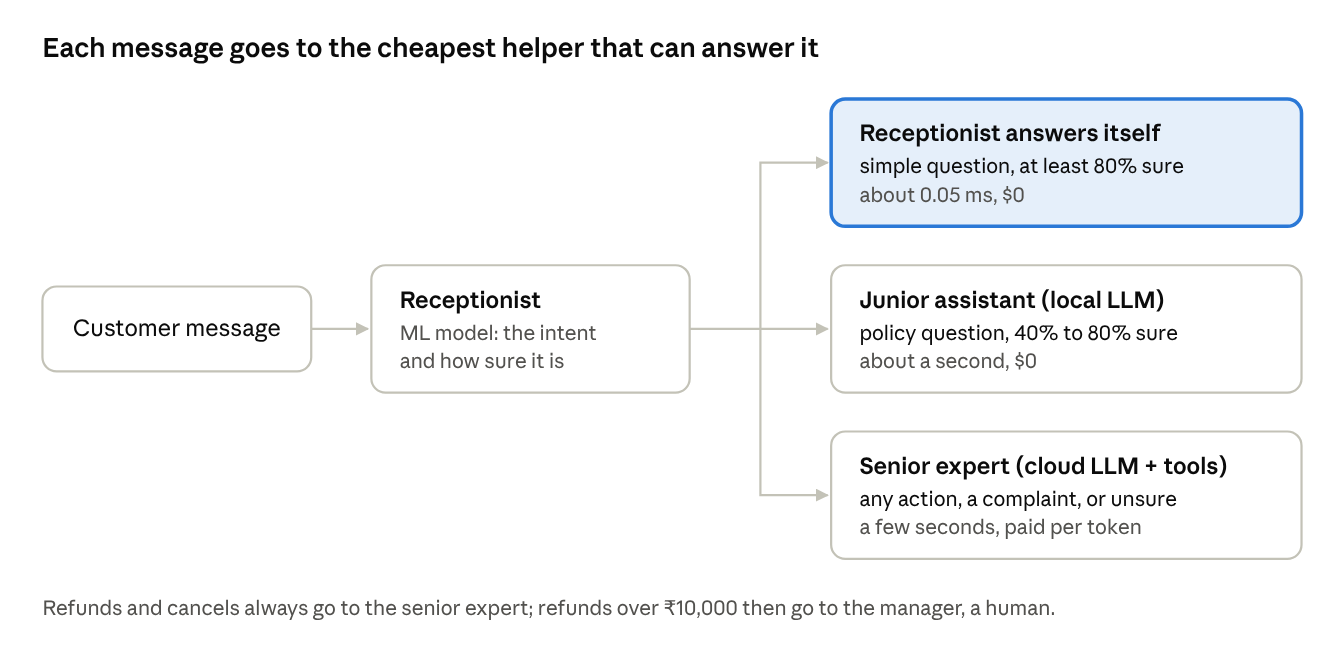

In [10]:
Image("../docs/images/support-office.png", width=700)

One example message for each helper (the same four used in the app and the README):

In [11]:
from budget_agent.router import Router

office = Router()

for helper, message in config.DEMO_MESSAGES.items():
    r = office.handle(message)
    who = config.HELPERS[r.layer] + (" → " + config.HELPERS["human"] if r.escalated else "")
    print(f"📨 {message}")
    print(f"   {who} · {r.seconds:.2f}s · ${r.cost_usd:.4f}")
    print(f"   💬 {r.reply[:160]}\n")

📨 track my order NM10009
   Receptionist (ML model) · 0.00s · $0.0000
   💬 Your order NM10009 (Running Shoes) is Shipped. Delivery date: 2026-10-08.

📨 kitne din me delivery hoti hai
   Junior assistant (local LLM) · 1.16s · $0.0000
   💬 Standard delivery mein 3-5 kaamre din, Express delivery mein 1-2 kaamre din hoti hai.

📨 my order NM10002 arrived broken, I want a refund
   Senior expert (cloud LLM agent) · 4.13s · $0.0029
   💬 Sorry about that — I’ve started the refund for order NM10002. The ₹5,999 should go back to your original payment method in 5–7 working days.

📨 refund NM10018, I don't like the chair
   Senior expert (cloud LLM agent) → Manager (human) · 4.09s · $0.0030
   💬 I’ve checked your order, and it’s eligible for a refund since it was delivered on 02 Oct 2026. Because the amount is ₹12,999, a human agent needs to approve it,



- The **receptionist** answered instantly, for free, with a real order lookup.
- The **junior assistant** (a small LLM on the laptop) answered a policy question in Hinglish, for free.
- The **senior expert** handled the refund with its tools.
- The ₹12,999 refund went to the **manager** (a human), because a rule *in our code* says so.

### Does it actually save money?

We sent 60 messages (a third of them messy) to the expert alone, and to the whole office:

In [12]:
results = pd.read_csv(config.BENCHMARK_CSV)
summary = pd.DataFrame({
    "cost per 1,000 messages ($)": [results.v2_cost.mean() * 1000, results.v4_cost.mean() * 1000],
    "average seconds": [results.v2_seconds.mean(), results.v4_seconds.mean()],
}, index=["Expert only (chapter 1)", "Whole office (chapter 3)"]).round(2)
summary

,"cost per 1,000 messages ($)",average seconds
Expert only (chapter 1),0.99,1.70
Whole office (chapter 3),0.52,1.04


The whole office is 1.9x cheaper and 1.6x faster, and 55% of messages cost nothing.


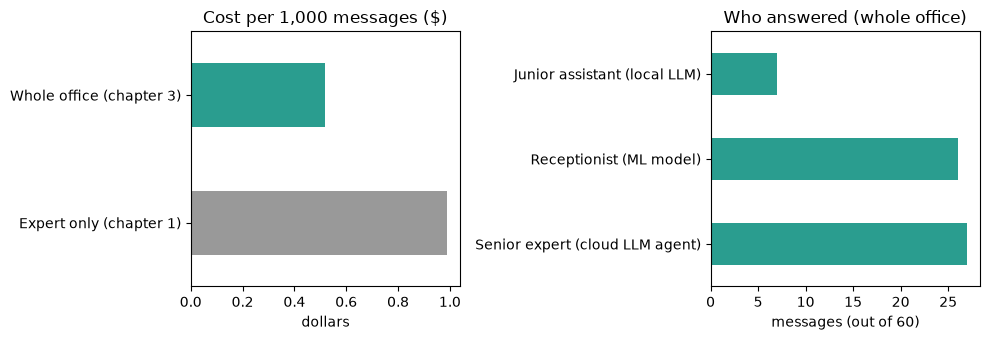

In [13]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))
summary["cost per 1,000 messages ($)"].plot.barh(ax=left, color=["#999999", "#2a9d8f"], title="Cost per 1,000 messages ($)")
results.v4_layer.map(config.HELPERS).value_counts().plot.barh(ax=right, color="#2a9d8f", title="Who answered (whole office)")
right.set_ylabel(""); right.set_xlabel("messages (out of 60)"); left.set_xlabel("dollars"); plt.tight_layout()

print(f"The whole office is {results.v2_cost.sum() / results.v4_cost.sum():.1f}x cheaper "
      f"and {results.v2_seconds.mean() / results.v4_seconds.mean():.1f}x faster, "
      f"and {(results.v4_layer != 'cloud_llm').mean():.0%} of messages cost nothing.")

---
## What we built, in one sentence

> An AI agent that uses a big LLM **only when it needs to**, a small ML model the LLM trained for the easy work,
> a free local model for simple policy questions, and a human for the risky cases.

That's **inference engineering**: picking the right model for each request, not one giant model for everything.

**Go deeper:** 01 (the data) · 02 (chapter 1) · 03 (chapter 2) · 04 (the local model) · 05 (chapter 3) ·
`docs/theory-guide.md` (every idea in plain English) · `docs/results.md` (every number).

In [14]:
saved_after = len(config.REPLAY_LOG.read_text().splitlines())
print(f"New (paid) LLM answers in this notebook: {saved_after - saved_before}")

New (paid) LLM answers in this notebook: 0
